# 🚔 LAPD Crime Intelligence — Notebook 1: Data Pipeline & EDA
**Covers:** Loading → Cleaning → Feature Engineering → EDA Plots → Save Parquet

> **Train/Test Split Strategy:** Year-based — Train: 2020–2023 | Test: 2024–2025

In [27]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── Paths ──────────────────────────────────────────────
BASE_DIR   = Path('D:\Coding Stuff\pps5').resolve()
DATA_DIR   = BASE_DIR / 'data';    DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = BASE_DIR / 'outputs'; OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR  = BASE_DIR / 'models';  MODEL_DIR.mkdir(exist_ok=True)

CSV_PATH   = BASE_DIR / 'data' / 'Crime_Data_from_2020_to_Present.csv'

TRAIN_YEARS = [2020, 2021, 2022, 2023]
TEST_YEARS  = [2024, 2025]

print(f'Base dir  : {BASE_DIR}')
print(f'CSV path  : {CSV_PATH}')
print(f'Train yrs : {TRAIN_YEARS}')
print(f'Test yrs  : {TEST_YEARS}')

Base dir  : D:\Coding Stuff\pps5
CSV path  : D:\Coding Stuff\pps5\data\Crime_Data_from_2020_to_Present.csv
Train yrs : [2020, 2021, 2022, 2023]
Test yrs  : [2024, 2025]


## 1️⃣ Load Dataset

In [28]:
chunks, chunk_size = [], 100_000
row_count = sum(1 for _ in open(CSV_PATH, encoding='latin-1')) - 1
print(f'Detected ~{row_count:,} rows')

with tqdm(total=row_count, desc='Reading CSV', unit='rows') as pbar:
    for chunk in pd.read_csv(CSV_PATH, chunksize=chunk_size,
                             encoding='latin-1', low_memory=False):
        chunks.append(chunk)
        pbar.update(len(chunk))

df_raw = pd.concat(chunks, ignore_index=True)
print(f'\nLoaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Detected ~1,004,991 rows


Reading CSV: 100%|██████████| 1004991/1004991 [00:04<00:00, 235828.76rows/s]



Loaded: 1,004,991 rows × 28 columns


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509


In [29]:
# Quick raw overview
print('Column dtypes and null counts:')
null_info = pd.DataFrame({
    'dtype'    : df_raw.dtypes,
    'nulls'    : df_raw.isnull().sum(),
    'null_pct' : (df_raw.isnull().mean() * 100).round(2),
    'nunique'  : df_raw.nunique()
})
null_info

Column dtypes and null counts:


,dtype,nulls,null_pct,nunique
DR_NO,int64,0,0.00,1004991
Date Rptd,object,0,0.00,1896
DATE OCC,object,0,0.00,1879
TIME OCC,int64,0,0.00,1439
AREA,int64,0,0.00,21
AREA NAME,object,0,0.00,21
Rpt Dist No,int64,0,0.00,1210
Part 1-2,int64,0,0.00,2
Crm Cd,int64,0,0.00,140
Crm Cd Desc,object,0,0.00,140


## 2️⃣ Standardise Column Names

In [30]:
RENAME_MAP = {
    'DR_NO': 'dr_no', 'Date Rptd': 'date_reported', 'DATE OCC': 'date_occurred',
    'TIME OCC': 'time_occurred', 'AREA': 'area', 'AREA NAME': 'area_name',
    'Rpt Dist No': 'rpt_dist_no', 'Part 1-2': 'part_1_2', 'Crm Cd': 'crm_cd',
    'Crm Cd Desc': 'crm_cd_desc', 'Mocodes': 'mocodes', 'Vict Age': 'vict_age',
    'Vict Sex': 'vict_sex', 'Vict Descent': 'vict_descent', 'Premis Cd': 'premis_cd',
    'Premis Desc': 'premis_desc', 'Weapon Used Cd': 'weapon_cd',
    'Weapon Desc': 'weapon_desc', 'Status': 'status', 'Status Desc': 'status_desc',
    'Crm Cd 1': 'crm_cd_1', 'Crm Cd 2': 'crm_cd_2', 'Crm Cd 3': 'crm_cd_3',
    'Crm Cd 4': 'crm_cd_4', 'LOCATION': 'location', 'Cross Street': 'cross_street',
    'LAT': 'lat', 'LON': 'lon',
    'Hour': 'hour', 'Month': 'month', 'DayOfWeek': 'day_of_week',
    'Year': 'year', 'Report Delay': 'report_delay',
}

df = df_raw.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df_raw.columns})
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
print('Columns after rename:', df.columns.tolist())

Columns after rename: ['dr_no', 'date_reported', 'date_occurred', 'time_occurred', 'area', 'area_name', 'rpt_dist_no', 'part_1_2', 'crm_cd', 'crm_cd_desc', 'mocodes', 'vict_age', 'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_cd', 'weapon_desc', 'status', 'status_desc', 'crm_cd_1', 'crm_cd_2', 'crm_cd_3', 'crm_cd_4', 'location', 'cross_street', 'lat', 'lon']


## 3️⃣ Clean Data

In [31]:
DESCENT_MAP = {
    'A': 'Other Asian', 'B': 'Black', 'C': 'Chinese', 'D': 'Cambodian',
    'F': 'Filipino', 'G': 'Guamanian', 'H': 'Hispanic/Latin',
    'I': 'American Indian', 'J': 'Japanese', 'K': 'Korean',
    'L': 'Laotian', 'O': 'Other', 'P': 'Pacific Islander',
    'S': 'Samoan', 'U': 'Hawaiian', 'V': 'Vietnamese',
    'W': 'White', 'X': 'Unknown', 'Z': 'Asian Indian',
}

CRIME_CATEGORY_MAP = [
    (range(100, 200), 'Homicide'),
    (range(200, 300), 'Rape/Sexual Assault'),
    (range(300, 400), 'Robbery'),
    (range(400, 500), 'Aggravated Assault'),
    (range(500, 600), 'Burglary'),
    (range(600, 700), 'Vehicle Theft'),
    (range(700, 800), 'Theft/Larceny'),
    (range(800, 900), 'Arson'),
]

def map_crime_category(code):
    try:
        c = int(code)
        for r, cat in CRIME_CATEGORY_MAP:
            if c in r: return cat
    except: pass
    return 'Other'

original_len = len(df)
print(f'Starting rows: {original_len:,}')

Starting rows: 1,004,991


In [32]:
# ── Drop report_delay ─────────────────────────────────────────────────────
if 'report_delay' in df.columns:
    df.drop(columns=['report_delay'], inplace=True)
    print('✅ Dropped report_delay')

# ── Parse dates ───────────────────────────────────────────────────────────
for col in ['date_reported', 'date_occurred']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', infer_datetime_format=True)

# ── Extract time features ─────────────────────────────────────────────────
if 'date_occurred' in df.columns:
    df['year']        = df['year'].fillna(df['date_occurred'].dt.year)   if 'year'        in df.columns else df['date_occurred'].dt.year
    df['month']       = df['month'].fillna(df['date_occurred'].dt.month) if 'month'       in df.columns else df['date_occurred'].dt.month
    df['day_of_week'] = df['date_occurred'].dt.dayofweek
    df['week']        = df['date_occurred'].dt.isocalendar().week.astype(int)
    df['day_of_year'] = df['date_occurred'].dt.dayofyear

if 'time_occurred' in df.columns and 'hour' not in df.columns:
    df['hour'] = (df['time_occurred'].fillna(0).astype(float).astype(int) // 100).clip(0, 23)
elif 'hour' not in df.columns:
    df['hour'] = 0

# KEY FIX: Keep year/month/hour as plain int64 (NOT Int16) so LightGBM is happy
for col in ['year', 'month', 'day_of_week', 'week', 'day_of_year', 'hour']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print('✅ Time features extracted')
print(df[['year','month','day_of_week','week','hour']].dtypes)

✅ Time features extracted
year           int64
month          int64
day_of_week    int64
week           int64
hour           int64
dtype: object


In [34]:
# ── Fix LAT / LON ─────────────────────────────────────────────────────────
before = len(df)
bad_coords = (
    df['lat'].isna() | df['lon'].isna() |
    (df['lat'] == 0) | (df['lon'] == 0)
)
df = df[~bad_coords].copy()
df = df[df['lat'].between(33.5, 34.5) & df['lon'].between(-119.0, -117.5)].copy()
print(f'✅ LAT/LON: removed {before - len(df):,} bad rows')

# ── Fix victim age ────────────────────────────────────────────────────────
if 'vict_age' in df.columns:
    df['vict_age']  = pd.to_numeric(df['vict_age'], errors='coerce')
    df['age_known'] = ((df['vict_age'] > 0) & (df['vict_age'] <= 100)).astype(int)
    df.loc[df['vict_age'] > 100, 'vict_age'] = np.nan
    df.loc[df['vict_age'] <= 0,  'vict_age'] = np.nan
    df['age_group'] = pd.cut(
        df['vict_age'],
        bins=[0, 17, 25, 35, 45, 55, 65, 100],
        labels=['<18','18-25','26-35','36-45','46-55','56-65','65+'],
        right=True
    )
    df['age_group'] = df['age_group'].cat.add_categories('Unknown').fillna('Unknown')
    print(f'✅ Age fixed: {df["age_known"].mean()*100:.1f}% known ages')

# ── Fix sex / descent ─────────────────────────────────────────────────────
if 'vict_sex' in df.columns:
    df['vict_sex'] = df['vict_sex'].astype(str).str.strip().str.upper()
    df.loc[~df['vict_sex'].isin({'M','F','X','H','N'}), 'vict_sex'] = 'X'
    df['vict_sex'] = df['vict_sex'].fillna('X')

if 'vict_descent' in df.columns:
    df['vict_descent']  = df['vict_descent'].astype(str).str.strip().str.upper().fillna('X')
    df['descent_label'] = df['vict_descent'].map(DESCENT_MAP).fillna('Unknown')

# ── Drop duplicates ───────────────────────────────────────────────────────
if 'dr_no' in df.columns:
    before = len(df)
    df.drop_duplicates(subset=['dr_no'], keep='first', inplace=True)
    print(f'✅ Removed {before - len(df):,} duplicate DR numbers')

# ── Drop missing core fields ──────────────────────────────────────────────
core = [c for c in ['area','crm_cd','year','month'] if c in df.columns]
before = len(df)
df.dropna(subset=core, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'✅ Dropped {before - len(df):,} rows missing core fields')
print(f'\nFinal clean rows: {len(df):,}')

✅ LAT/LON: removed 0 bad rows
✅ Age fixed: 73.2% known ages
✅ Removed 0 duplicate DR numbers
✅ Dropped 0 rows missing core fields

Final clean rows: 1,002,751


In [35]:
# ── Convert numeric cols to plain int/float (NO Int16 — avoids LightGBM error) ──
int_plain  = ['area','crm_cd','rpt_dist_no','premis_cd','part_1_2']
for c in int_plain:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(-1).astype(int)

print('Dtypes of key columns:')
print(df[['area','crm_cd','year','month','hour','vict_age']].dtypes)

Dtypes of key columns:
area          int64
crm_cd        int64
year          int64
month         int64
hour          int64
vict_age    float64
dtype: object


## 4️⃣ Feature Engineering

In [36]:
# Cyclical encoding for temporal features
df['hour_sin']  = np.sin(2 * np.pi * df['hour']        / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']        / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month']       / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']       / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Time of day bucket
df['time_of_day'] = pd.cut(
    df['hour'], bins=[-1, 5, 11, 17, 20, 23],
    labels=['Late Night','Morning','Afternoon','Evening','Night']
)
df['is_weekend']       = df['day_of_week'].isin([5, 6]).astype(int)
df['crime_category']   = df['crm_cd'].apply(map_crime_category)

# Area log density
area_counts = df.groupby('area')['crm_cd'].count().rename('area_total_crimes')
df = df.merge(area_counts, on='area', how='left')
df['area_log_density'] = np.log1p(df['area_total_crimes'])

# Property crime flag
if 'premis_cd' in df.columns:
    df['is_property_crime'] = (df['premis_cd'].fillna(0).astype(float) >= 500).astype(int)

print('✅ Feature engineering complete')
print(f'Total columns: {df.shape[1]}')

✅ Feature engineering complete
Total columns: 49


## 5️⃣ Year-Based Train / Test Split

In [37]:
df_train = df[df['year'].isin(TRAIN_YEARS)].copy().reset_index(drop=True)
df_test  = df[df['year'].isin(TEST_YEARS)].copy().reset_index(drop=True)

print('=' * 50)
print(f'  TRAIN  ({TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]}): {len(df_train):>10,} rows')
print(f'  TEST   ({TEST_YEARS[0]}–{TEST_YEARS[-1]}):  {len(df_test):>10,} rows')
print(f'  TOTAL:                    {len(df):>10,} rows')
print(f'  Test %: {len(df_test)/len(df)*100:.1f}%')
print('=' * 50)

# Verify no leakage
assert df_train['year'].max() <= 2023, 'LEAKAGE: future year in train!'
assert df_test['year'].min()  >= 2024, 'LEAKAGE: past year in test!'
print('✅ No temporal leakage confirmed')

  TRAIN  (2020–2023):    875,087 rows
  TEST   (2024–2025):     127,664 rows
  TOTAL:                     1,002,751 rows
  Test %: 12.7%
✅ No temporal leakage confirmed


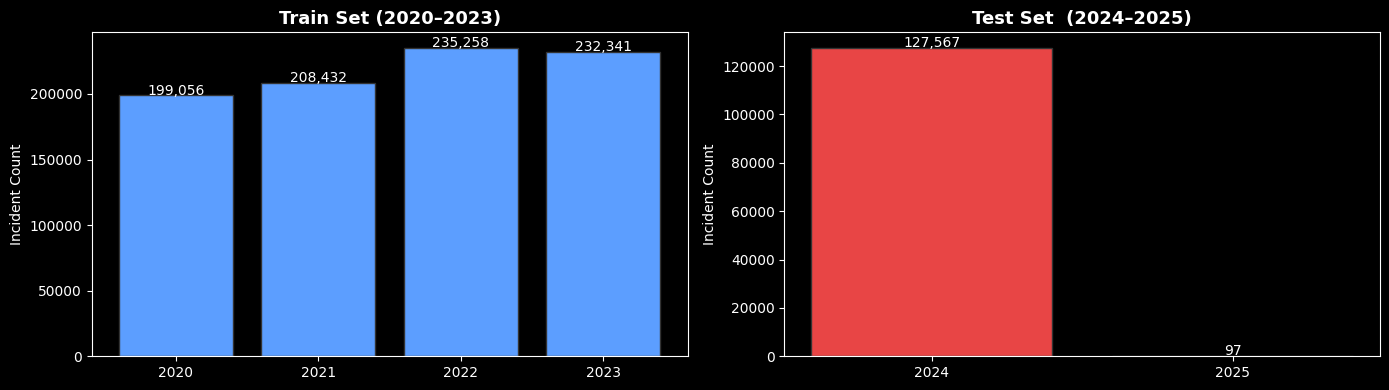

In [38]:
# Year distribution in each split
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (split_df, title, color) in zip(axes, [
    (df_train, 'Train Set (2020–2023)', '#5C9EFF'),
    (df_test,  'Test Set  (2024–2025)', '#E84545')
]):
    yr_counts = split_df.groupby('year').size()
    ax.bar(yr_counts.index.astype(str), yr_counts.values, color=color, edgecolor='#333')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Incident Count')
    for bar, val in zip(ax.patches, yr_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'train_test_split.png', dpi=150)
plt.show()

## 6️⃣ EDA Plots

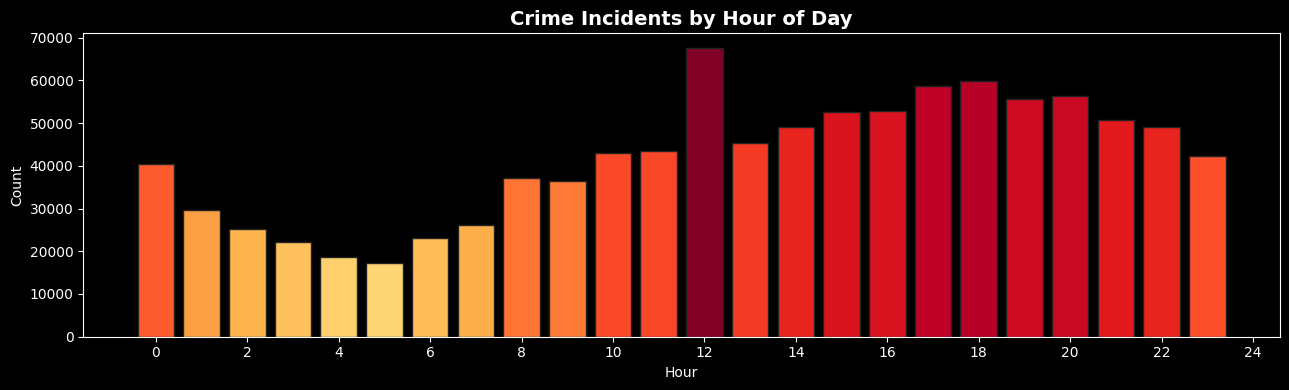

In [39]:
# ── 1. Crime by Hour ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
hourly = df.groupby('hour').size()
norm   = hourly / hourly.max()
bars   = ax.bar(hourly.index, hourly.values,
                color=plt.cm.YlOrRd(norm.values), edgecolor='#222')
ax.set_title('Crime Incidents by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Count')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'crime_by_hour.png', dpi=150)
plt.show()

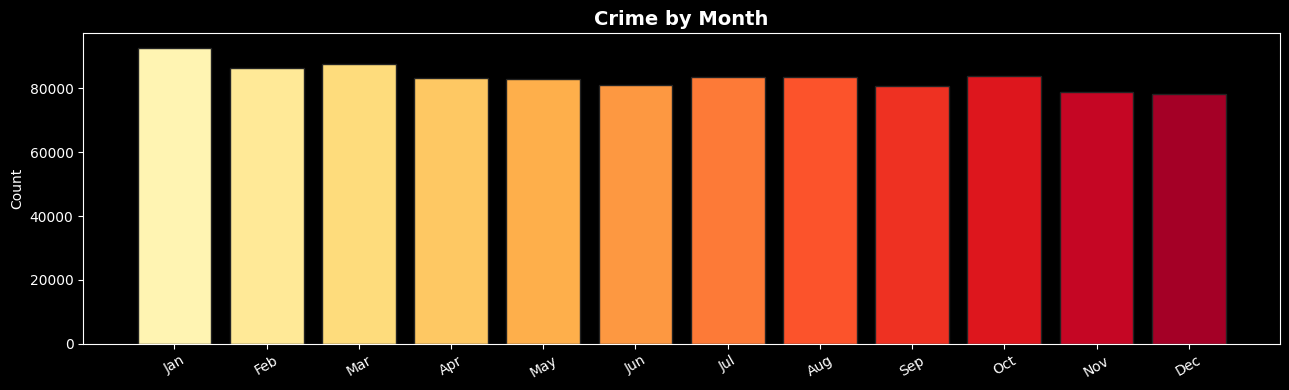

In [40]:
# ── 2. Crime by Month ─────────────────────────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(13, 4))
monthly = df.groupby('month').size()
ax.bar(monthly.index, monthly.values,
       color=sns.color_palette('YlOrRd', 12), edgecolor='#222')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names, rotation=30)
ax.set_title('Crime by Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'crime_by_month.png', dpi=150)
plt.show()

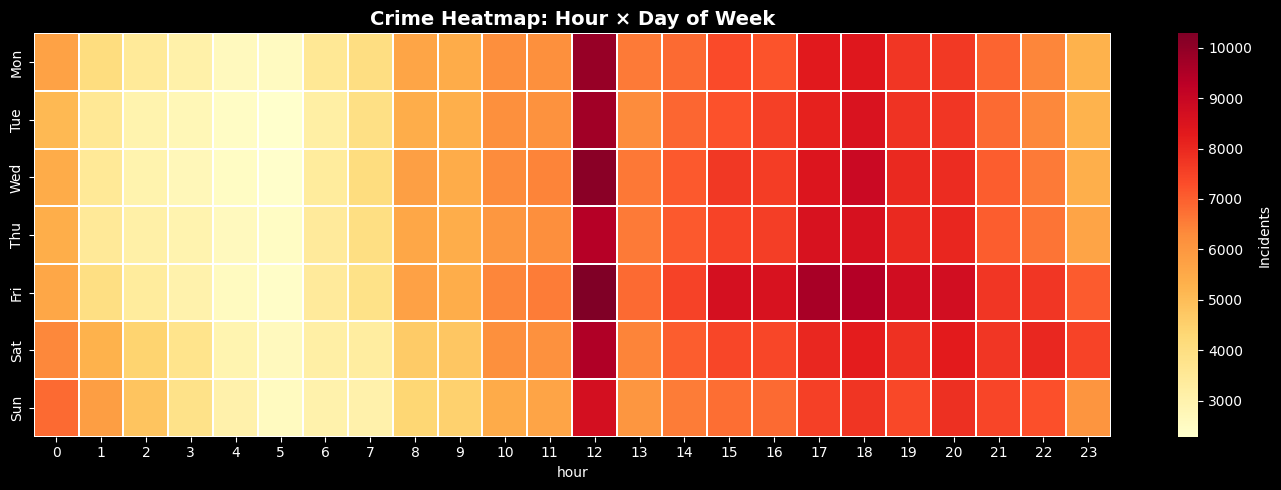

In [41]:
# ── 3. Heatmap: Hour × Day of Week ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
pivot = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.2,
            cbar_kws={'label': 'Incidents'})
ax.set_title('Crime Heatmap: Hour × Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_hour_dow.png', dpi=150)
plt.show()

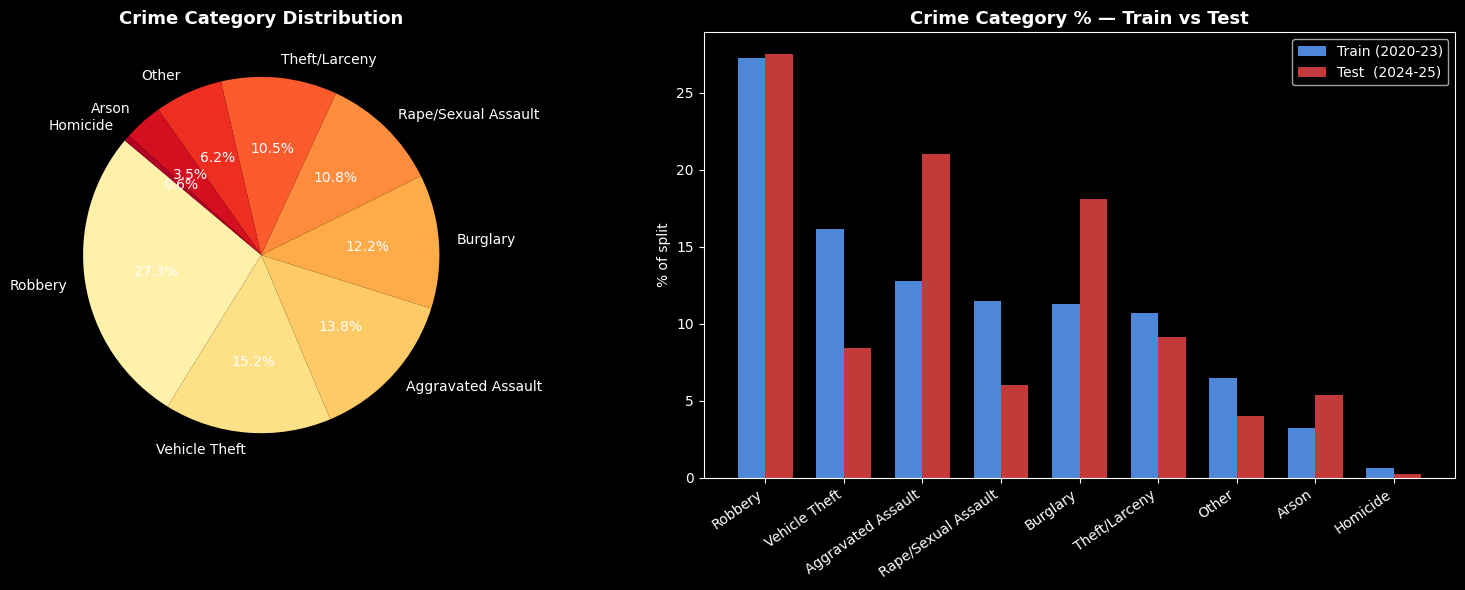

In [42]:
# ── 4. Crime Category Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cat_counts = df['crime_category'].value_counts()

# Pie chart
axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('YlOrRd', len(cat_counts)), startangle=140)
axes[0].set_title('Crime Category Distribution', fontsize=13, fontweight='bold')

# Bar chart with train vs test comparison
train_cat = df_train['crime_category'].value_counts(normalize=True) * 100
test_cat  = df_test['crime_category'].value_counts(normalize=True)  * 100
cats      = train_cat.index
x = np.arange(len(cats)); w = 0.35
axes[1].bar(x - w/2, [train_cat.get(c,0) for c in cats], w,
            label='Train (2020-23)', color='#5C9EFF', alpha=0.85)
axes[1].bar(x + w/2, [test_cat.get(c,0) for c in cats], w,
            label='Test  (2024-25)', color='#E84545', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats, rotation=35, ha='right')
axes[1].set_title('Crime Category % — Train vs Test', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% of split'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'crime_category_dist.png', dpi=150)
plt.show()

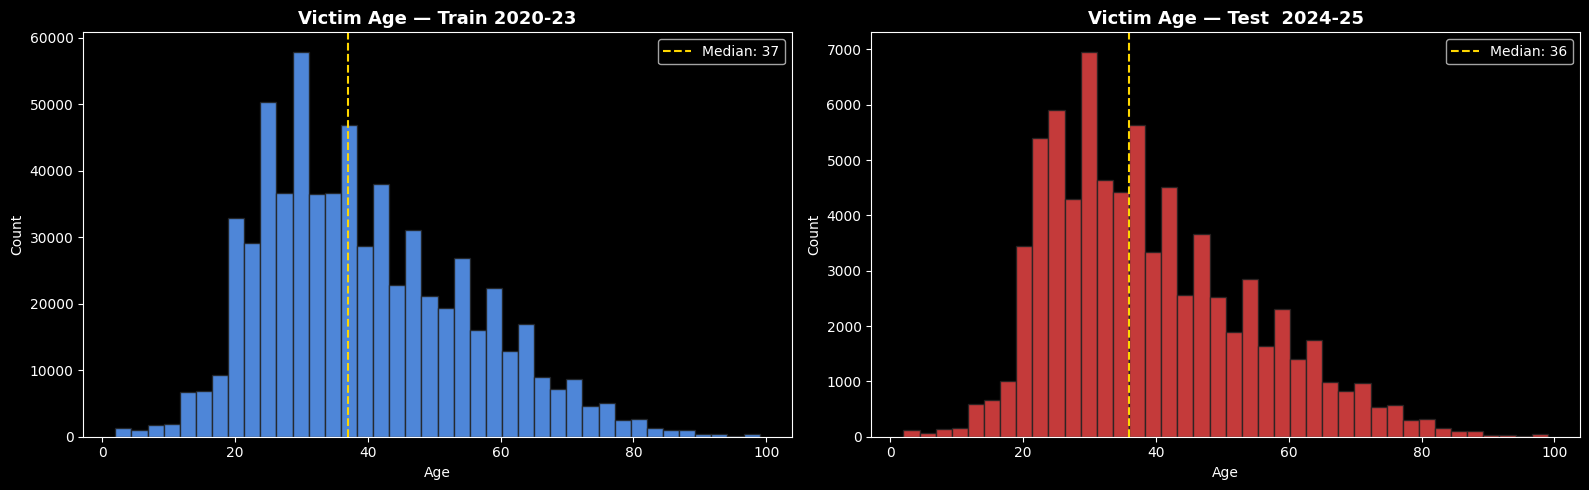

In [43]:
# ── 5. Victim Age — known ages only, train vs test ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (split_df, label, color) in zip(axes, [
    (df_train, 'Train 2020-23', '#5C9EFF'),
    (df_test,  'Test  2024-25', '#E84545')
]):
    known = split_df[split_df.get('age_known', pd.Series(0, index=split_df.index)) == 1]['vict_age'].dropna()
    ax.hist(known, bins=40, color=color, edgecolor='#222', alpha=0.85)
    ax.axvline(known.median(), color='gold', linestyle='--',
               label=f'Median: {known.median():.0f}')
    ax.set_title(f'Victim Age — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Age'); ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'victim_age_clean.png', dpi=150)
plt.show()

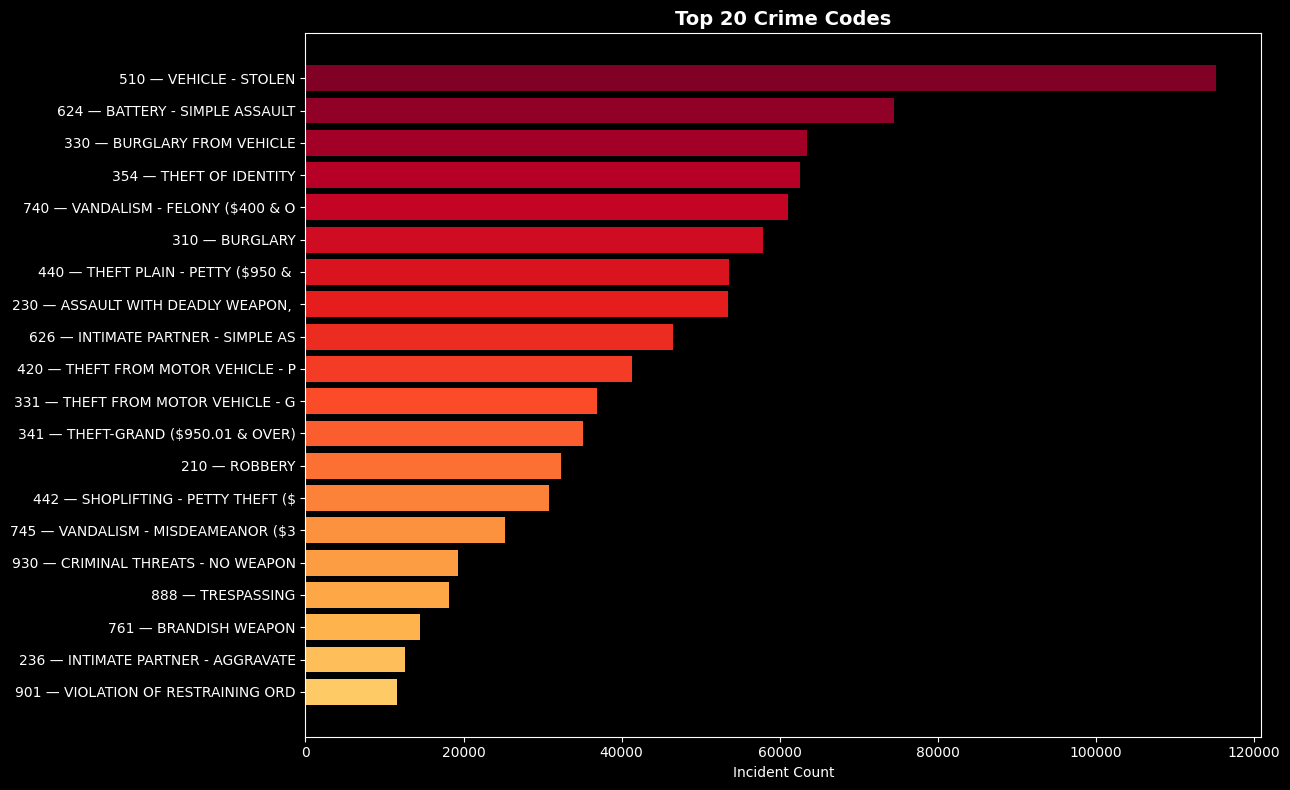

In [44]:
# ── 6. Top 20 Crime Codes ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
top20 = df.groupby('crm_cd').size().sort_values(ascending=False).head(20)
if 'crm_cd_desc' in df.columns:
    desc_map = df.drop_duplicates('crm_cd').set_index('crm_cd')['crm_cd_desc']
    labels   = [f"{c} — {str(desc_map.get(c,''))[:28]}" for c in top20.index]
else:
    labels = top20.index.astype(str).tolist()
colors = plt.cm.YlOrRd(np.linspace(0.3, 1.0, 20))[::-1]
ax.barh(labels, top20.values, color=colors)
ax.invert_yaxis()
ax.set_title('Top 20 Crime Codes', fontsize=14, fontweight='bold')
ax.set_xlabel('Incident Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top20_crimes.png', dpi=150)
plt.show()

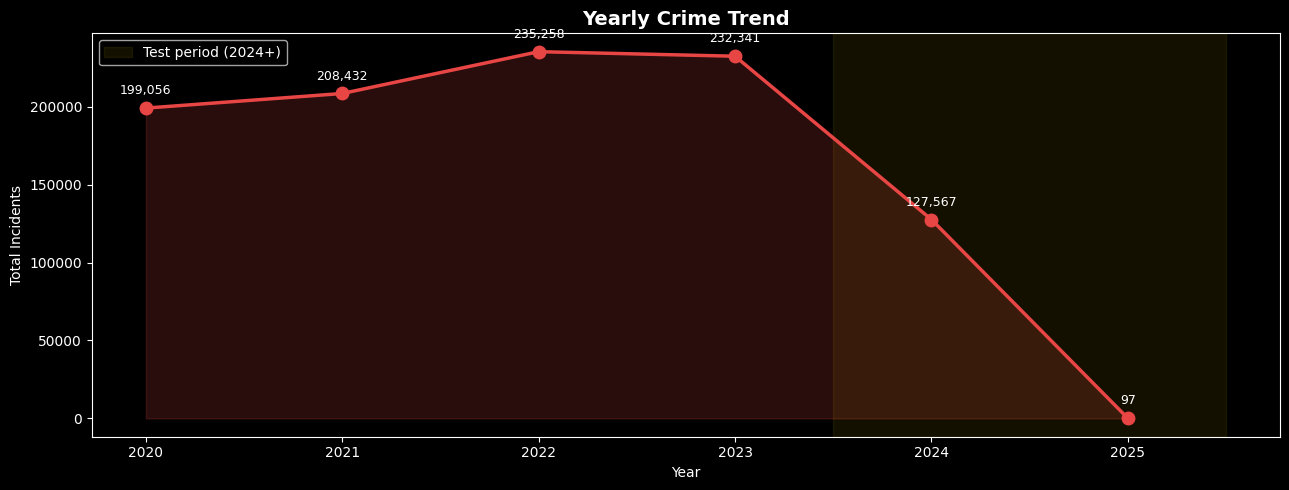

In [45]:
# ── 7. Yearly trend ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
yearly = df.groupby('year').size()
ax.plot(yearly.index, yearly.values, 'o-', color='#E84545', linewidth=2.5, markersize=9)
ax.fill_between(yearly.index, yearly.values, alpha=0.18, color='#E84545')
ax.axvspan(2023.5, yearly.index.max() + 0.5, alpha=0.08, color='gold',
           label='Test period (2024+)')
for yr, cnt in zip(yearly.index, yearly.values):
    ax.annotate(f'{cnt:,}', (yr, cnt), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Yearly Crime Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Incidents'); ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'yearly_trend.png', dpi=150)
plt.show()

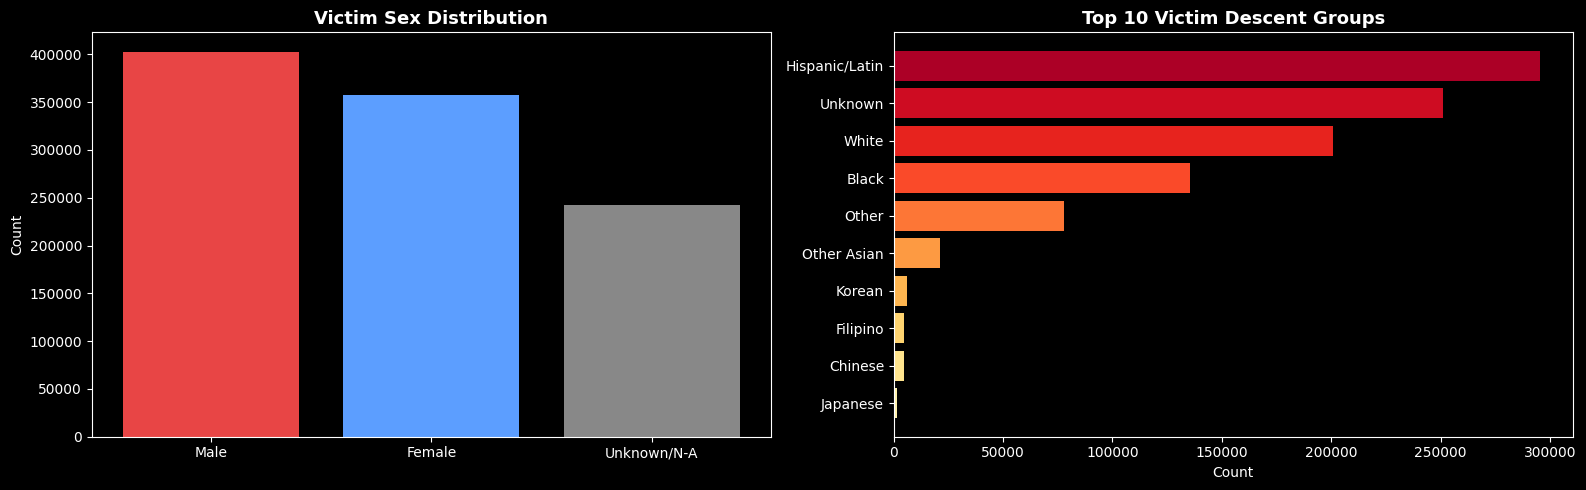

In [46]:
# ── 8. Victim sex + descent ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sex_map   = {'M':'Male','F':'Female','X':'Unknown/N-A'}
sex_counts= df['vict_sex'].map(sex_map).value_counts() if 'vict_sex' in df.columns else pd.Series()
axes[0].bar(sex_counts.index, sex_counts.values,
            color=['#E84545','#5C9EFF','#888888'])
axes[0].set_title('Victim Sex Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

if 'descent_label' in df.columns:
    dc = df['descent_label'].value_counts().head(10)
    axes[1].barh(dc.index, dc.values,
                 color=sns.color_palette('YlOrRd_r', 10))
    axes[1].invert_yaxis()
    axes[1].set_title('Top 10 Victim Descent Groups', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'victim_sex_descent.png', dpi=150)
plt.show()

## 7️⃣ Save Clean Parquets

In [47]:
# Full clean dataset
df.to_parquet(DATA_DIR / 'clean_crime.parquet', index=False, compression='snappy')
df_train.to_parquet(DATA_DIR / 'train_crime.parquet', index=False, compression='snappy')
df_test.to_parquet(DATA_DIR / 'test_crime.parquet',  index=False, compression='snappy')

# Area centroids (for heatmap)
centroids = (
    df[df['lat'].notna() & df['lon'].notna()]
    .groupby('area')
    .agg(lat=('lat','median'), lon=('lon','median'))
    .reset_index()
)
centroids.to_parquet(DATA_DIR / 'area_centroids.parquet', index=False)

print(f'✅ clean_crime.parquet : {(DATA_DIR/"clean_crime.parquet").stat().st_size/1e6:.1f} MB')
print(f'✅ train_crime.parquet : {(DATA_DIR/"train_crime.parquet").stat().st_size/1e6:.1f} MB')
print(f'✅ test_crime.parquet  : {(DATA_DIR/"test_crime.parquet").stat().st_size/1e6:.1f} MB')
print(f'✅ area_centroids.parquet saved ({len(centroids)} areas)')

✅ clean_crime.parquet : 52.8 MB
✅ train_crime.parquet : 46.4 MB
✅ test_crime.parquet  : 6.2 MB
✅ area_centroids.parquet saved (21 areas)


In [48]:
# Final summary
print('='*60)
print('  PIPELINE COMPLETE — DATA QUALITY SUMMARY')
print('='*60)
print(f'  Clean rows          : {len(df):>10,}')
print(f'  Train rows (≤2023)  : {len(df_train):>10,}')
print(f'  Test rows  (≥2024)  : {len(df_test):>10,}')
print(f'  Years               : {int(df["year"].min())} – {int(df["year"].max())}')
print(f'  Unique areas        : {df["area"].nunique()}')
print(f'  Unique crime codes  : {df["crm_cd"].nunique()}')
if 'age_known' in df.columns:
    print(f'  Age known %         : {df["age_known"].mean()*100:.1f}%')
print('='*60)

  PIPELINE COMPLETE — DATA QUALITY SUMMARY
  Clean rows          :  1,002,751
  Train rows (≤2023)  :    875,087
  Test rows  (≥2024)  :    127,664
  Years               : 2020 – 2025
  Unique areas        : 21
  Unique crime codes  : 140
  Age known %         : 73.2%
